# Bike Sharing - Data Preprocessing

In [ ]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## settings for plots
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns',None)

## 1. Load data

In [2]:
## load data
df = pd.read_csv('../project_data/raw/hour.csv')
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 2. Data quality assessment

In [3]:
print(df.isnull().sum())
print(f"\n Total rows: {len(df)}")

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

 Total rows: 17379


In [4]:
## check for impossible values
positive_col = df.select_dtypes(include=['int', 'float'])

for col in positive_col:
    # check if negative values
    neg_count = (df[col]<0).sum()

    if neg_count:
        print(f'{col}: has negative values')
        print(f'Samples: ')
        print(f'{df_demo[df[col]<0].head(3)}')

if neg_count == 0:
    print('no negative values')

no negative values


In [5]:
df['dteday'] = pd.to_datetime(df['dteday']) 

In [55]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'cnt_rolling', 'cnt_rolling_week',
       'cnt_rolling_month', 'cnt_rolling_1month', 'cnt_rolling_2months'],
      dtype='object')

In [ ]:
# display heatmap
plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r') 
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Data preprocessing

### Step 1: Handle missing target values (before split)
*there are no missing target values in our dataset.*

### Step 2: Simple cleaning

#### 2a. Removing duplicate rows
*there are no duplicate rows in our dataset.*

#### 2b. Fixing obvious data entry errors (e.g., age = 999)
*there are no obvious data entry errors in our dataset.*

#### 2c. Removing impossible values (e.g., negative prices)
*there are no impossible values in our dataset.*

#### 2d. Remove unnecessary variables
We need to remove `instant` because it is simply a unique identifier for each hour, and doesn't provide information about the environment, time of day/year, etc.  

We also remove `dteday`, the date, because we are not modeling the bike rental count as a time series. We are just regressing the variables on bike count, to discover relationships between it and these variables, in a general sense. Also, we already have columns for the hour of the day, month, season etc., so the aspects about time that we care about most will still remain for the problem.  

In [10]:
df1 = df.drop(columns={'instant', 'dteday'})

### Step 3: Train-test split

In [11]:
# create feature matrix and target array
X = df1.drop('cnt',axis=1)
y = df1['cnt']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17379, 14)
y shape: (17379,)


In [15]:
# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4950)

print("X train shape:", X_train.shape)
print("X test shape:", X_test.shape)

print("y train shape:", y_train.shape)
print("y test shape:", y_test.shape)

X train shape: (13903, 14)
X test shape: (3476, 14)
y train shape: (13903,)
y test shape: (3476,)


### Step 4: Handle missing feature values
See below. There are no missing feature values.  

In [16]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13903 entries, 15346 to 5997
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      13903 non-null  int64  
 1   yr          13903 non-null  int64  
 2   mnth        13903 non-null  int64  
 3   hr          13903 non-null  int64  
 4   holiday     13903 non-null  int64  
 5   weekday     13903 non-null  int64  
 6   workingday  13903 non-null  int64  
 7   weathersit  13903 non-null  int64  
 8   temp        13903 non-null  float64
 9   atemp       13903 non-null  float64
 10  hum         13903 non-null  float64
 11  windspeed   13903 non-null  float64
 12  casual      13903 non-null  int64  
 13  registered  13903 non-null  int64  
dtypes: float64(4), int64(10)
memory usage: 1.6 MB


### Step 5: Handle outliers

First, we extract only those columns which are numerical (i.e., measurements of something on a continuous or integer scale , rather than an indicator). Then we count the number of quantile-based outliers, those observations outside of [lower bound, upper bound]. 

In [33]:
numerical_columns = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']

for column in numerical_columns:
    print("Column:", column)

    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    outliers = X_train[(X_train[column]<lower_bound) | (X_train[column]>upper_bound)]

    print(f"normal range: [{lower_bound:.2f}, {upper_bound:.2f}]")

    outliers = X_train[(X_train[column]<lower_bound)|(X_train[column]>upper_bound)]
    print(f"outliers: {len(outliers)}\n")

Column: temp
normal range: [-0.14, 1.14]
outliers: 0

Column: atemp
normal range: [-0.10, 1.05]
outliers: 0

Column: hum
normal range: [0.03, 1.23]
outliers: 19

Column: windspeed
normal range: [-0.12, 0.48]
outliers: 255

Column: casual
normal range: [-62.00, 114.00]
outliers: 971

Column: registered
normal range: [-246.00, 498.00]
outliers: 541



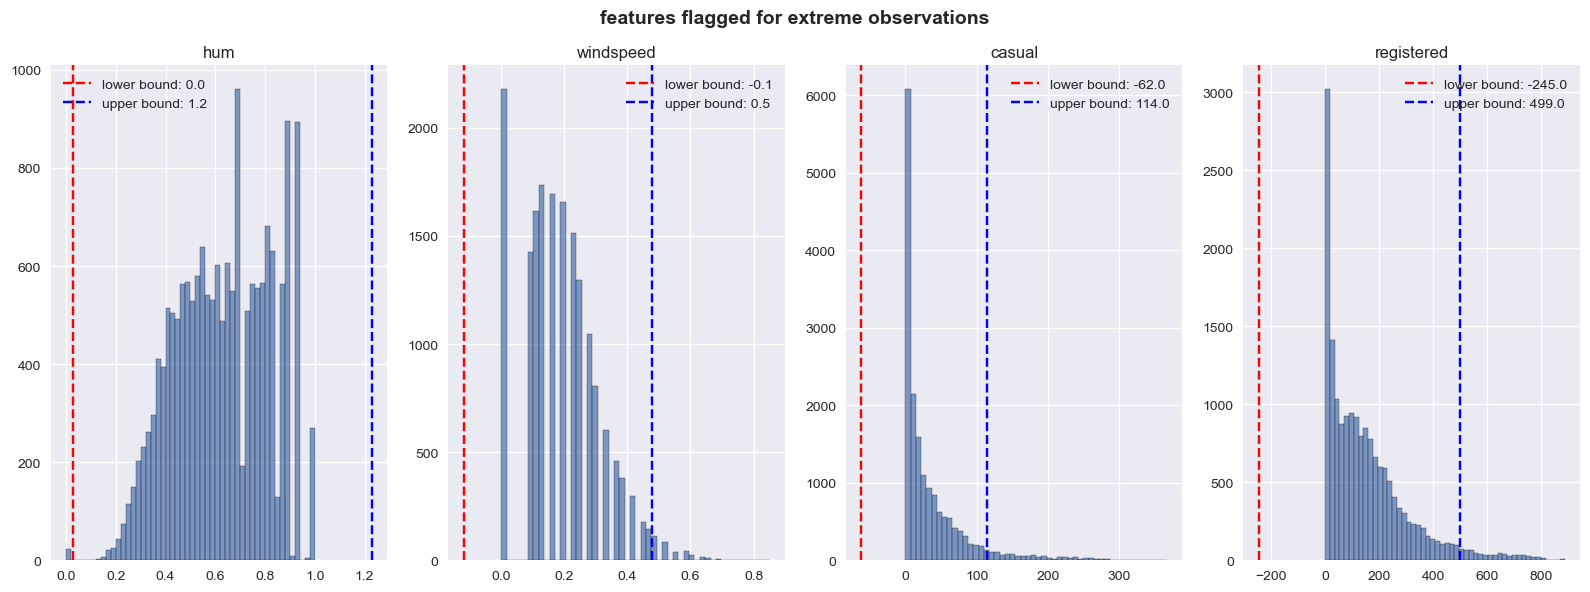

In [41]:
columns_with_extreme_obs = ['hum', 'windspeed', 'casual', 'registered']

# histograms for all features
f, ax = plt.subplots(1, 4, figsize=(16, 6))
ax = ax.flatten()

for i, col in enumerate(columns_with_extreme_obs):
    # calculate quartiles and IQR per column
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # plot histogram
    ax[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    ax[i].set_title(col)
    ax[i].set_xlabel('')

    # add vertical lines to the correct subplot
    ax[i].axvline(lower_bound, c='r', ls='--', label=f'lower bound: {lower_bound:.1f}')
    ax[i].axvline(upper_bound, c='b', ls='--', label=f'upper bound: {upper_bound:.1f}')

    ax[i].legend()

plt.suptitle('features flagged for extreme observations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data validation

In [42]:
print("=" * 50)
print("STEP 7: Final Validation")
print("=" * 50)

# Check for missing values
print("\n1. Missing Values:")
print(f"   X_train: {X_train.isnull().sum().sum()} missing")
print(f"   X_test:  {X_test.isnull().sum().sum()} missing")
print(f"   y_train: {y_train.isnull().sum()} missing")
print(f"   y_test:  {y_test.isnull().sum()} missing")

# Check for infinite values
print("\n2. Infinite Values:")
print(f"   X_train: {np.isinf(X_train).sum().sum()} infinite")
print(f"   X_test:  {np.isinf(X_test).sum().sum()} infinite")

# Final shapes
print("\n3. Final Shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test:  {y_test.shape}")

print("\n All validation checks passed!")

STEP 7: Final Validation

1. Missing Values:
   X_train: 0 missing
   X_test:  0 missing
   y_train: 0 missing
   y_test:  0 missing

2. Infinite Values:
   X_train: 0 infinite
   X_test:  0 infinite

3. Final Shapes:
   X_train: (13903, 14)
   X_test:  (3476, 14)
   y_train: (13903,)
   y_test:  (3476,)

 All validation checks passed!


In [ ]:
# import os
# import pickle

# # Create directory
# os.makedirs('../data/processed', exist_ok=True)

# # Save processed data
# X_train.to_csv('../data/processed/X_train.csv', index=False)
# X_train.to_csv('../data/processed/X_test.csv', index=False)
# y_train.to_csv('../data/processed/y_train.csv', index=False)
# y_test.to_csv('../data/processed/y_test.csv', index=False)

## 5. Build baseline model

In [43]:
## train baseline model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
## predict
y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

## evaluate
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

In [45]:
print('Baseline Model Performance (NO feature engineering)')
print('=' * 50)
print(f'{"Metric":<10} {"Train":>12} {"Test":>12}')
print('-' * 50)
print(f'{"R²":<10} {train_r2:>12.4f} {test_r2:>12.4f}')
print(f'{"RMSE":<10} {train_rmse:>12.4f} {test_rmse:>12.4f}')

Baseline Model Performance (NO feature engineering)
Metric            Train         Test
--------------------------------------------------
R²               1.0000       1.0000
RMSE             0.0000       0.0000


In [46]:
## save baseline performance for comparison
baseline_r2 = test_r2
baseline_rmse = test_rmse

print(f'\nBaseline to beat: R² = {baseline_r2:.4f}')


Baseline to beat: R² = 1.0000
